In [1]:
!pip -q install nilearn nibabel pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 52.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets, plotting
from nilearn.glm.first_level import FirstLevelModel

In [3]:
localizer = datasets.fetch_localizer_first_level()

fmri_img = localizer.epi_img
events = pd.read_csv(localizer.events, sep="\t")

events.head()

[fetch_localizer_first_level] Added README.md to /root/nilearn_data

[fetch_localizer_first_level] Dataset created in /root/nilearn_data/localizer_first_level

[fetch_localizer_first_level] Downloading data from https://osf.io/2bqxn/download ...

[fetch_localizer_first_level] Downloaded 8396800 of 34532740 bytes (24.3%%,    3.1s remaining)

[fetch_localizer_first_level]  ...done. (4 seconds, 0 min)

[fetch_localizer_first_level] Extracting data from 
/root/nilearn_data/localizer_first_level/cac0ef0f4307834e60fedd2a0448862a/download...

[fetch_localizer_first_level] .. done.

,trial_type,onset,duration
0,visual_computation,0.0,1.0
1,visual_computation,2.4,1.0
2,horizontal_checkerboard,8.7,1.0
3,audio_right_hand_button_press,11.4,1.0
4,sentence_listening,15.0,1.0


In [4]:
fmri_glm = FirstLevelModel(
    t_r=2.4,
    slice_time_ref=0.5,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    smoothing_fwhm=5,
    minimize_memory=False
)

fmri_glm = fmri_glm.fit(fmri_img, events=events)
print("Model fitted successfully.")

Model fitted successfully.


Index(['audio_computation', 'audio_left_hand_button_press',
       'audio_right_hand_button_press', 'horizontal_checkerboard',
       'sentence_listening', 'sentence_reading', 'vertical_checkerboard',
       'visual_computation', 'visual_left_hand_button_press',
       'visual_right_hand_button_press', 'drift_1', 'drift_2', 'drift_3',
       'drift_4', 'drift_5', 'drift_6', 'constant'],
      dtype='object')


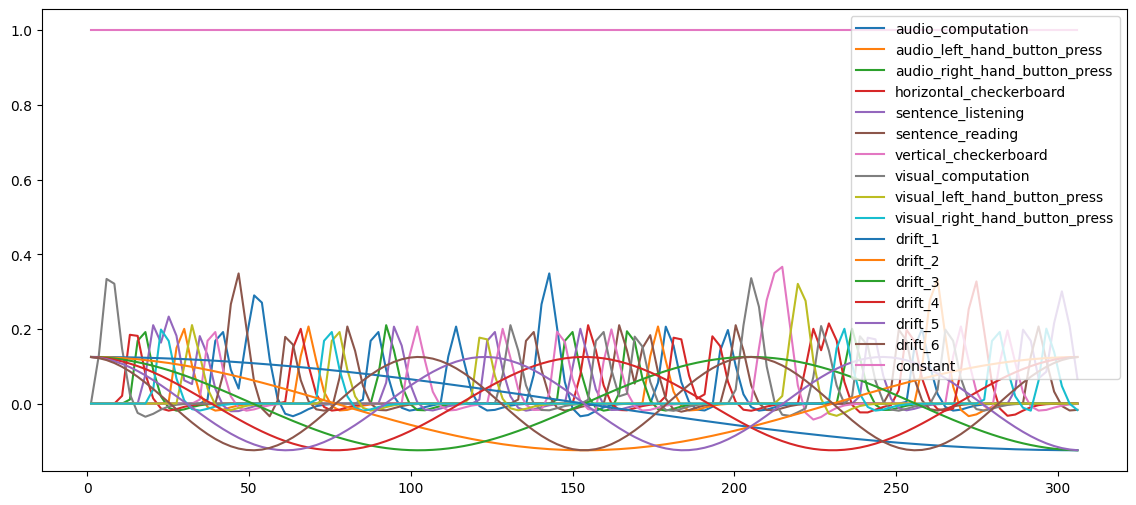

In [5]:
design_matrix = fmri_glm.design_matrices_[0]
print(design_matrix.columns)

design_matrix.plot(figsize=(14,6))
plt.show()

In [6]:
contrast = "sentence_reading - sentence_listening"
z_map = fmri_glm.compute_contrast(
    contrast,
    output_type="z_score"
)

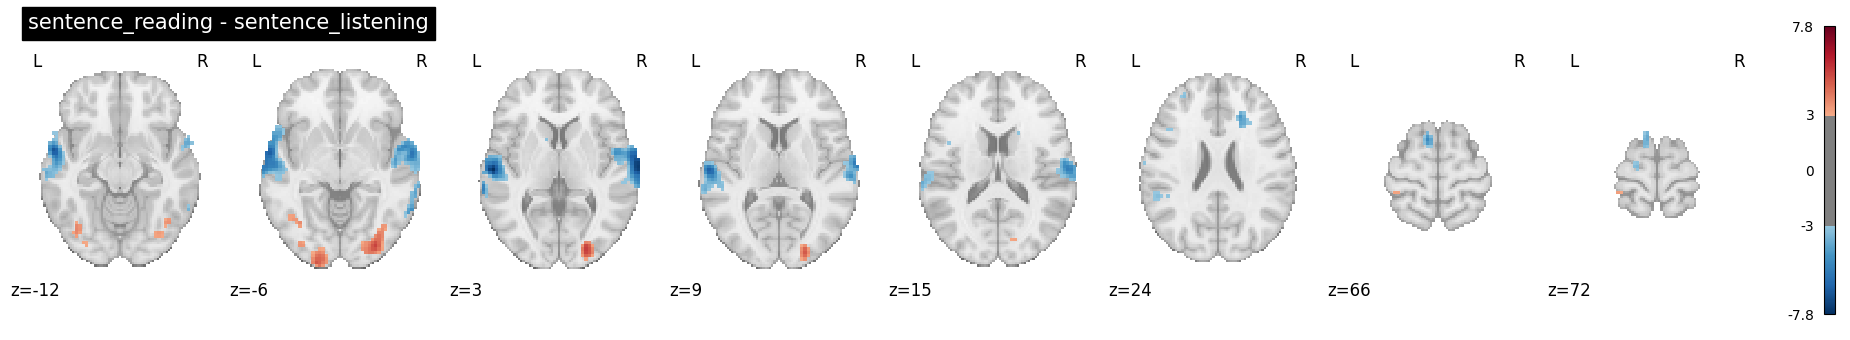

In [7]:
plotting.plot_stat_map(
    z_map,
    threshold=3.0,
    display_mode="z",
    cut_coords=8,
    title=contrast
)
plotting.show()